## Ensemble spread as a multiboxplot

When a weather forecast is run as an **ensemble** — dozens of slightly
different model runs that each evolve differently — the key question is
not just "what is the most likely value?" but "how uncertain is the
forecast, and how does that uncertainty change over time?"

A **multiboxplot** (also called a letter-value plot) answers that
question in a single chart.  For every time step it draws a stack of
nested boxes:

| Part | What it shows |
|------|---------------|
| Thin whisker line | Full range (0th–100th percentile) |
| Widest box | 10th–90th percentile spread |
| Middle box | 25th–75th interquartile range |
| Horizontal bar | Median (50th percentile) |

The boxes get **wider** as they approach the median and **darker** toward
the edges, making it easy to read the centre of the distribution at a
glance while still seeing the tails.

This notebook walks through the chart step-by-step, from loading
ensemble data through to overlaying the ensemble mean as a reference
line.

### Imports

We need three packages:

- **`earthkit.data`** to fetch sample data
- **`earthkit.plots`** for the chart
- **`xarray`** — we call `xr.set_options(keep_attrs=True)` so that unit
  and variable-name metadata survive arithmetic operations like `.mean()`
  (without this, the attributes are silently dropped and earthkit-plots
  cannot auto-label axes or convert units)

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import xarray as xr

xr.set_options(keep_attrs=True)

### Loading the data

The `"timeseries.json"` sample is a short ECMWF ensemble forecast
(ENFO stream) for a single location.  It contains **50 ensemble members**
(`number` dimension) spread across **145 time steps** (`t` dimension)
covering about two weeks from 13–28 November 2024.

`to_xarray()` converts the earthkit FieldList into an `xr.Dataset` with
all variables and coordinates already populated.

In [2]:
ds = ekd.from_source("sample", "timeseries.json").to_xarray()
ds

timeseries.json:   0%|          | 0.00/690k [00:00<?, ?B/s]

<xarray.Dataset> Size: 234kB
Dimensions:    (latitude: 1, longitude: 1, levelist: 1, number: 50,
                datetime: 1, t: 145)
Coordinates:
  * latitude   (latitude) float64 8B -9.104
  * longitude  (longitude) float64 8B 38.81
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 400B 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50
  * datetime   (datetime) <U20 80B '2024-11-13T00:00:00Z'
  * t          (t) datetime64[us] 1kB 2024-11-13 ... 2024-11-28
Data variables:
    tcc        (latitude, longitude, levelist, number, datetime, t) float64 58kB ...
    10v        (latitude, longitude, levelist, number, datetime, t) float64 58kB ...
    2t         (latitude, longitude, levelist, number, datetime, t) float64 58kB ...
    ssrd       (latitude, longitude, levelist, number, datetime, t) float64 58kB ...
Attributes:
    class:          od
    Forecast date:  2024-11-13T00:00:00Z
    domain:         g
    expver:         0001
    levtype:        sfc
    number:         1
    stream:         enfo
    type:           pf

### Selecting the variable

The dataset contains several variables.  We pick `"2t"` (2-metre
temperature).  After `squeeze()` the result has shape
`(number=50, t=145)` — 50 ensemble members at 145 time steps.

This is exactly the shape `multiboxplot` expects: one dimension to
**reduce over** (the ensemble `number` dimension) and one to use as the
**x axis** (the time `t` dimension).

In [3]:
t2m = ds["2t"]
print(t2m.dims, t2m.shape)

('latitude', 'longitude', 'levelist', 'number', 'datetime', 't') (1, 1, 1, 50, 1, 145)


### The minimal chart

`ekp.timeseries.multiboxplot` is the one-liner shortcut.  It:

1. Creates a `TimeSeries` subplot for you automatically
2. Auto-detects the time dimension (`t`) as the x axis
3. Computes quantiles along the remaining dimension (`number`) at each
   time step
4. Draws the nested box structure

The `units="celsius"` argument converts the raw Kelvin values to °C
**before** computing the quantiles, so all box positions, tick labels, and
axis labels are already in the requested units.

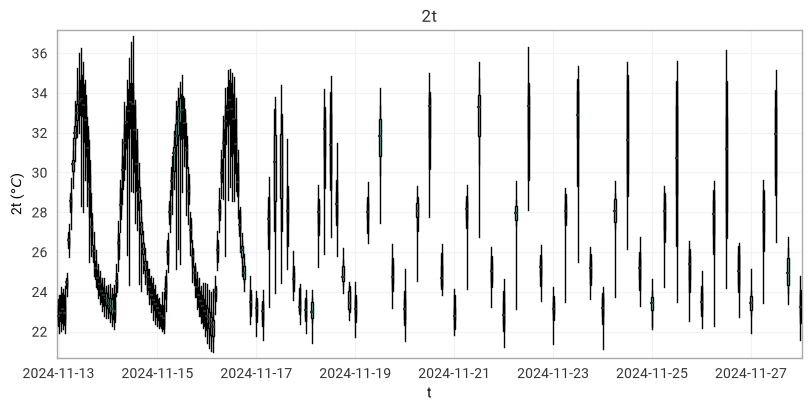

In [4]:
ekp.timeseries.multiboxplot(t2m, units="celsius").show()

### Resampling to a coarser time resolution

With 145 time steps at 6-hourly intervals, the boxes are very narrow and
tightly packed.  The `resample` argument groups the data into wider
windows before quantile computation, producing fewer but more legible
boxes.

`resample="12h"` computes 12-hour block means across all ensemble members
before computing quantiles.  The result has roughly half as many columns,
so each box is twice as wide and easier to read.

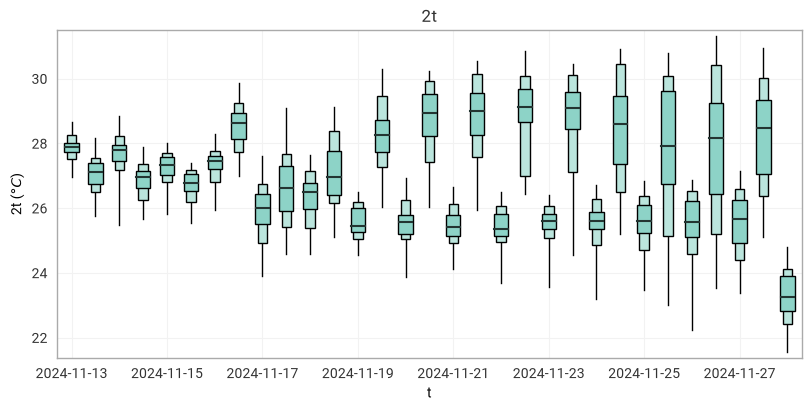

In [5]:
ekp.timeseries.multiboxplot(t2m, units="celsius", resample="12h").show()

### Overlaying the ensemble mean

The multiboxplot shows the spread, but it is useful to also show the
**ensemble mean** as a single reference line so readers can trace the
central forecast trajectory without having to estimate the midpoint of
each box visually.

`ekp.timeseries.multiboxplot` returns the `TimeSeries` chart object, so
you can chain `.line()` on it to add any further layers.  The
`units="celsius"` and `resample="12h"` arguments must be repeated so
the mean line is computed in the same units and at the same time
resolution as the boxes.

`zorder=10` places the line on top of all the box patches, which are
drawn at zorder 3–5.

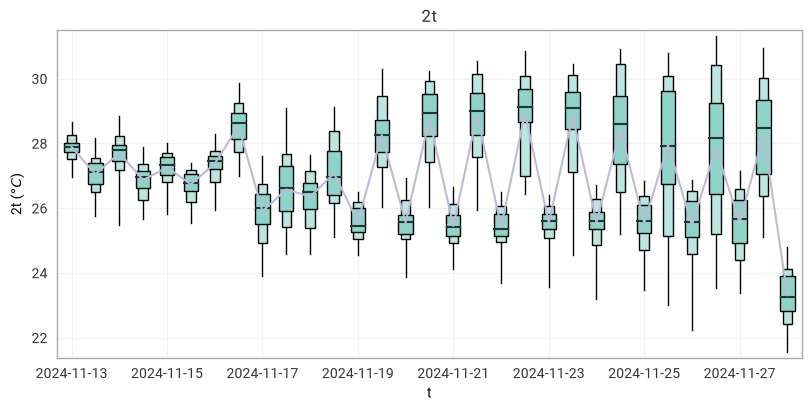

In [6]:
(
    ekp.timeseries.multiboxplot(t2m, units="celsius", resample="12h")
    .line(t2m.mean(dim="number"), units="celsius", resample="12h", zorder=10)
    .show()
)

### Decorating the chart

earthkit-plots uses **format strings** for titles and labels.
Placeholders like `{variable_name}` and `{units}` are filled in from the
data's metadata at render time, so the same template works across
different variables and unit choices.

`xticks` accepts the same `frequency` / `format` arguments as pandas
date formatters.  `"D"` produces one tick per day; `"%d %b"` formats as
"13 Nov".

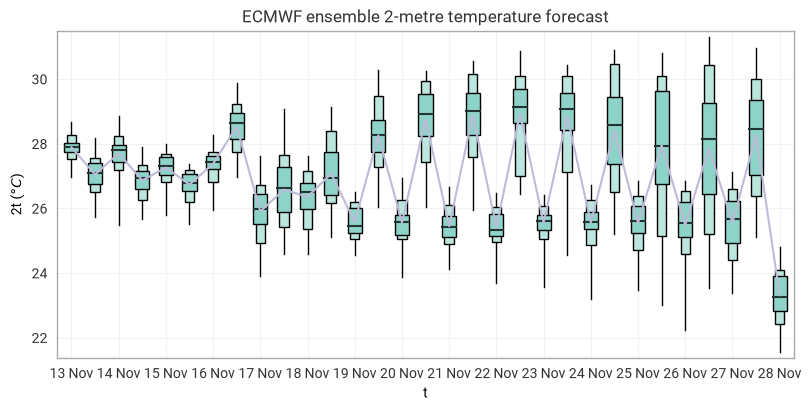

In [7]:
(
    ekp.timeseries.multiboxplot(t2m, units="celsius", resample="12h")
    .line(t2m.mean(dim="number"), units="celsius", resample="12h", zorder=10)
    .xticks(frequency="D", format="%d %b")
    .ylabel("{variable_name} ({units})")
    .title("ECMWF ensemble 2-metre temperature forecast")
    .show()
)

### Adding a quantile legend

The nested boxes are self-explanatory once you know the convention, but
for a publication or presentation you can attach a small diagram that
labels each quantile tier.  `multiboxplot_legend()` creates a miniature
replica of the box structure beside the main axes and annotates it with
the quantile percentages.

This method is available on the `TimeSeries` object returned by the
shortcut; it does not need to be called in the chain — you can call it
after assigning the chart to a variable.

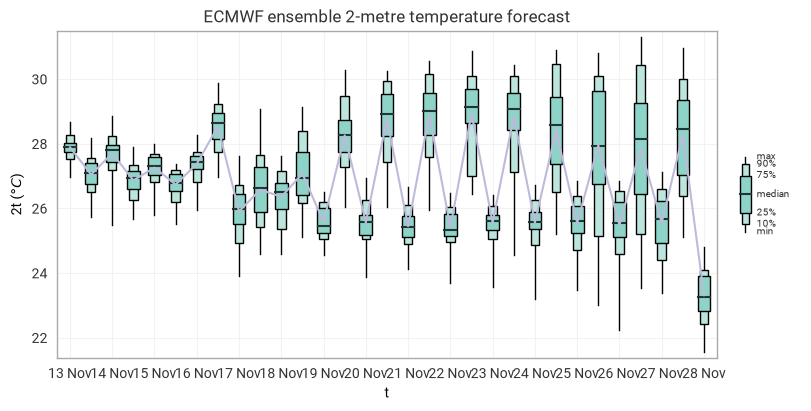

In [8]:
chart = (
    ekp.timeseries.multiboxplot(t2m, units="celsius", resample="12h")
    .line(t2m.mean(dim="number"), units="celsius", resample="12h", zorder=10)
    .xticks(frequency="D", format="%d %b")
    .ylabel("{variable_name} ({units})")
    .title("ECMWF ensemble 2-metre temperature forecast")
)

chart.multiboxplot_legend()
chart.show()